In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# train-test split
from sklearn.model_selection import train_test_split

# Scaling data
from sklearn.preprocessing import StandardScaler

# Linear Regression
from sklearn.linear_model import LinearRegression

# Model evaluation
from sklearn.metrics import r2_score

In [2]:
# Setting colour palette
sns.set_palette("Blues_d")

In [3]:
# Reading dataset
df = pd.read_csv('/workspaces/Linear_Regression_project/data/medical_cost.csv')

In [4]:
# displaying first 10 rows of the dataset
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
# data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
# duplicate records
print(f'Medical cost dataset containts {df.duplicated().sum()} duplicate records')

Medical cost dataset containts 1 duplicate records


In [7]:
# Removing duplicate records
df.drop_duplicates(inplace=True)

In [8]:
# Missing values
print(f'Meidcal cost dataset contains {df.isnull().sum().sum()} missing values')

Meidcal cost dataset contains 0 missing values


In [9]:
# Inspecting object types for data quality
obj_cols = list(df.select_dtypes(include='str').columns)

for col in obj_cols:
    values = []
    for value in df[col].unique():
        values.append(value)
    print(f'{col}: {values}', end='\n\n')

sex: ['female', 'male']

smoker: ['yes', 'no']

region: ['southwest', 'southeast', 'northwest', 'northeast']



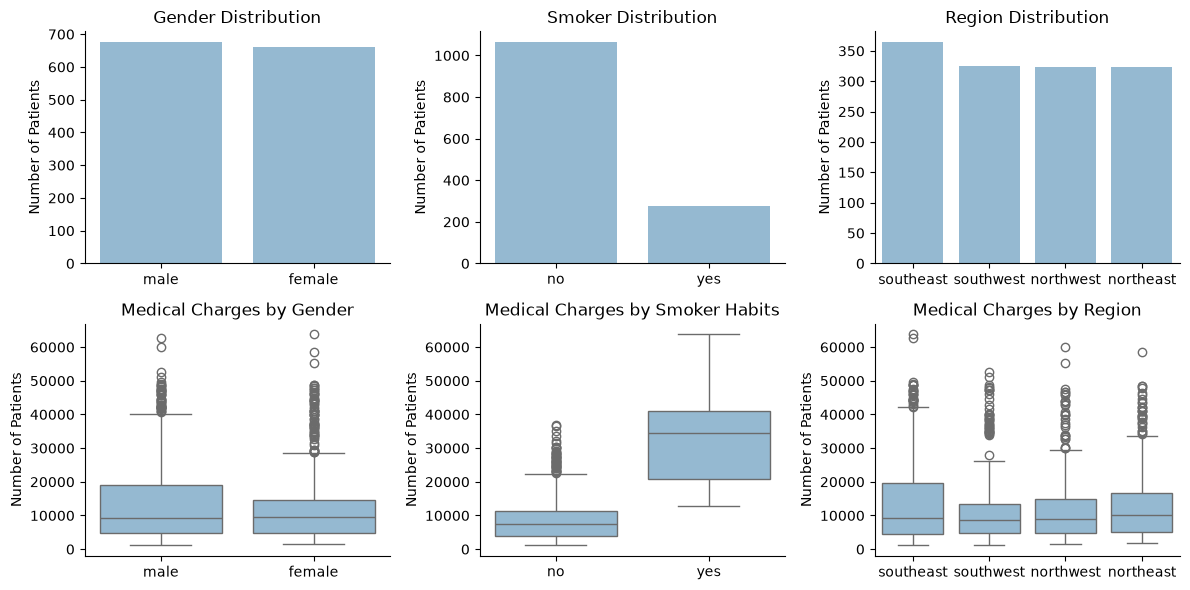

In [10]:
# Visualizing categorical distributions

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))     

sns.countplot(data=df, x='sex', order=df['sex'].value_counts().index, ax = axs [0][0])
axs[0][0].set_title('Gender Distribution')
axs[0][0].set_xlabel('')
axs[0][0].set_ylabel('Number of Patients')
axs[0][0].spines[['top', 'right']].set_visible(False)

sns.countplot(data=df, x='smoker', order=df['smoker'].value_counts().index, ax = axs [0][1])
axs[0][1].set_title('Smoker Distribution')
axs[0][1].set_xlabel('')
axs[0][1].set_ylabel('Number of Patients')
axs[0][1].spines[['top', 'right']].set_visible(False)

sns.countplot(data=df, x='region', order=df['region'].value_counts().index, ax = axs [0][2])
axs[0][2].set_title('Region Distribution')
axs[0][2].set_xlabel('')
axs[0][2].set_ylabel('Number of Patients')
axs[0][2].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='sex', y = 'charges', order=df['sex'].value_counts().index, ax = axs [1][0])
axs[1][0].set_title('Medical Charges by Gender')
axs[1][0].set_xlabel('')
axs[1][0].set_ylabel('Number of Patients')
axs[1][0].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='smoker', y = 'charges', order=df['smoker'].value_counts().index, ax = axs [1][1])
axs[1][1].set_title('Medical Charges by Smoker Habits')
axs[1][1].set_xlabel('')
axs[1][1].set_ylabel('Number of Patients')
axs[1][1].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='region', y = 'charges', order=df['region'].value_counts().index, ax = axs [1][2])
axs[1][2].set_title('Medical Charges by Region')
axs[1][2].set_xlabel('')
axs[1][2].set_ylabel('Number of Patients')
axs[1][2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


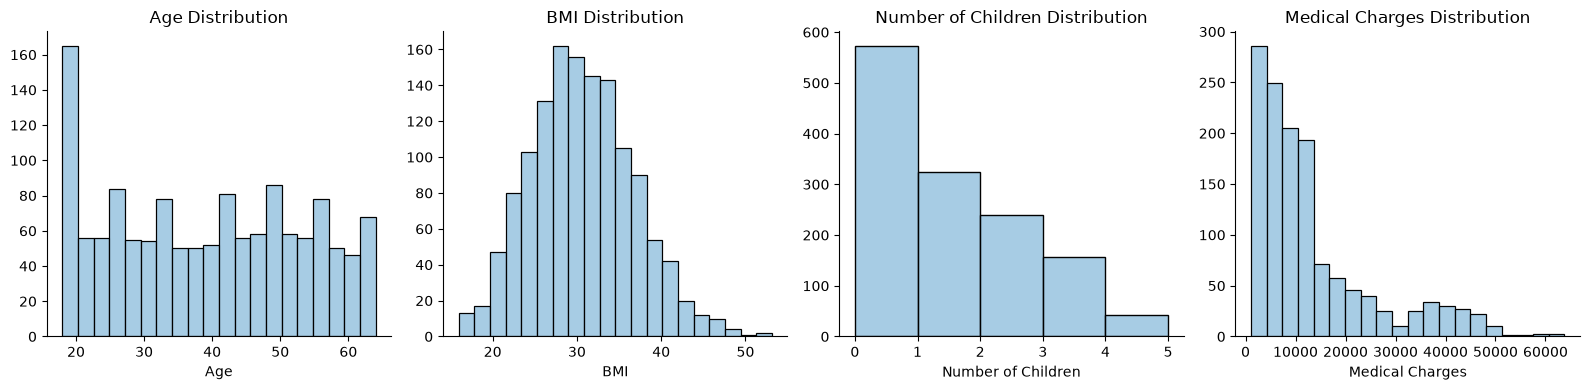

In [11]:
# Visualizing numerical distributions

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

sns.histplot(data=df, x='age', bins=20, ax=axs[0])
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('')
axs[0].spines[['top', 'right']].set_visible(False)

sns.histplot(data=df, x='bmi', bins=20, ax=axs[1])
axs[1].set_title('BMI Distribution')
axs[1].set_xlabel('BMI')
axs[1].set_ylabel('')
axs[1].spines[['top', 'right']].set_visible(False)

sns.histplot(data=df, x='children', bins=5, ax=axs[2])
axs[2].set_title('Number of Children Distribution')
axs[2].set_xlabel('Number of Children')
axs[2].set_ylabel('')
axs[2].spines[['top', 'right']].set_visible(False)

sns.histplot(data=df, x='charges', bins=20, ax=axs[3])
axs[3].set_title('Medical Charges Distribution')
axs[3].set_xlabel('Medical Charges')
axs[3].set_ylabel('')
axs[3].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


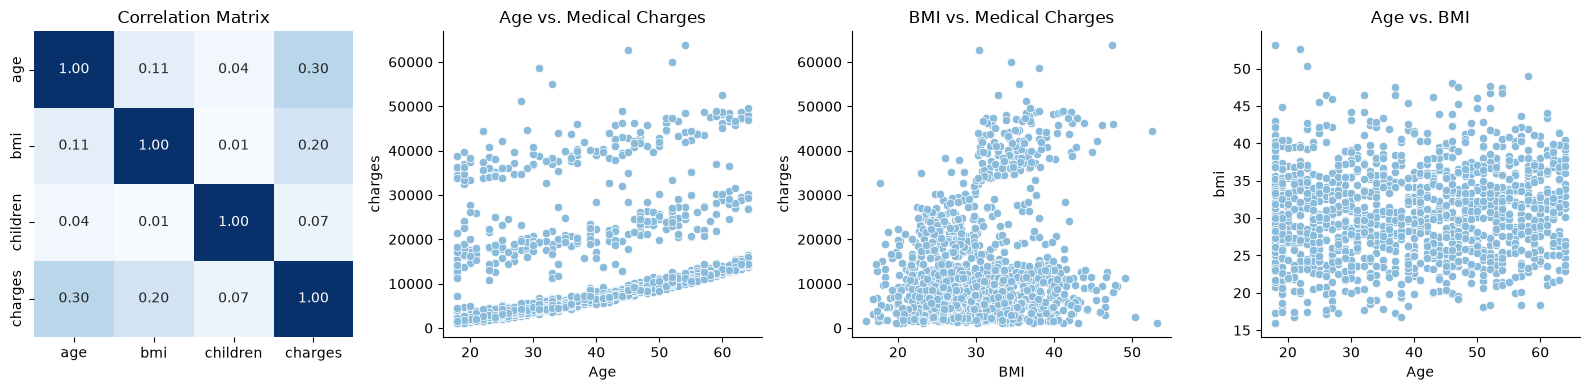

In [12]:
# Visualizing correlations

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

sns.heatmap(data= df.select_dtypes(exclude='object').corr(), annot=True, cmap='Blues', fmt='.2f', cbar = False, ax=axs[0])
axs[0].set_title('Correlation Matrix')
axs[0].spines[['top', 'right']].set_visible(False)


sns.scatterplot(data=df, x='age', y='charges', ax=axs[1])
axs[1].set_title('Age vs. Medical Charges')
axs[1].set_xlabel('Age')
axs[1].spines[['top', 'right']].set_visible(False)

sns.scatterplot(data=df, x='bmi', y='charges', ax=axs[2])
axs[2].set_title('BMI vs. Medical Charges')
axs[2].set_xlabel('BMI')
axs[2].spines[['top', 'right']].set_visible(False)

sns.scatterplot(data=df, x='age', y='bmi', ax=axs[3])
axs[3].set_title('Age vs. BMI')
axs[3].set_xlabel('Age')
axs[3].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


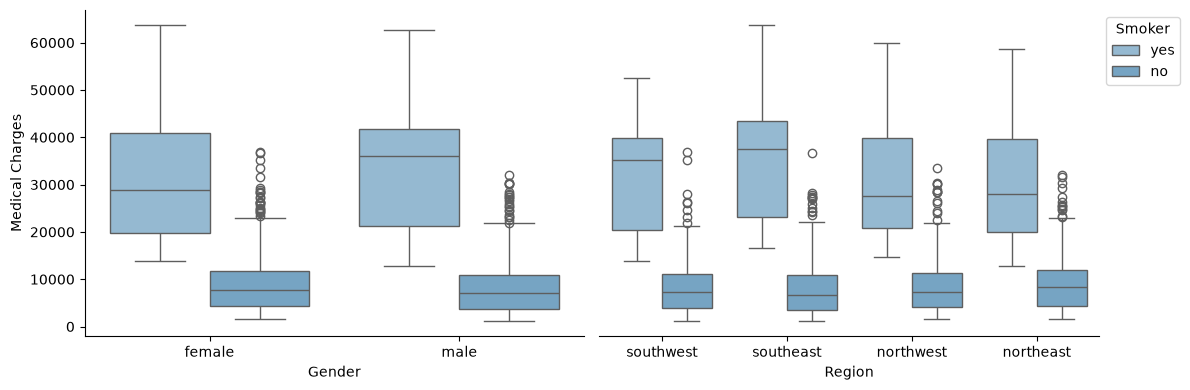

In [13]:
# Relation with variables
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Relation between smoker and sex on charges
sns.boxplot(data=df, x='sex', y='charges', hue='smoker', ax=axs[0])
axs[0].set_title('')
axs[0].set_xlabel('Gender')
axs[0].set_ylabel('Medical Charges')
axs[0].spines[['top', 'right']].set_visible(False)  
axs[0].legend().set_visible(False)

# Relation between region and sex on charges
sns.boxplot(data=df, x='region', y='charges', hue='smoker', ax=axs[1])
axs[1].set_title('')
axs[1].set_xlabel('Region')
axs[1].set_ylabel('') 
axs[1].set_yticks([])
axs[1].spines[['top', 'left','right']].set_visible(False) 
axs[1].legend(bbox_to_anchor=(1, 1), loc='upper left', title='Smoker')

plt.tight_layout()
plt.show()


In [14]:
# Outlier treatment
num_cols = list(df.select_dtypes(exclude='object').columns)

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])



In [15]:
# one-hot encoding 

obj_cols = list(df.select_dtypes(include='object').columns)

df = pd.get_dummies(data=df, columns=obj_cols, drop_first=True)

bool_cols = list(df.select_dtypes(include='bool').columns)
for col in bool_cols:
    df[col] = df[col].astype(int)

df.head(10)

/tmp/ipykernel_2334/1585988623.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = list(df.select_dtypes(include='object').columns)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
5,31,25.740,0,3756.62160,0,0,0,1,0
6,46,33.440,1,8240.58960,0,0,0,1,0
7,37,27.740,3,7281.50560,0,0,1,0,0
8,37,29.830,2,6406.41070,1,0,0,0,0
9,60,25.840,0,28923.13692,0,0,1,0,0


In [16]:
# train-test split

x = df.drop('charges', axis = 1)
y = df['charges']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1) 


In [19]:
# Scaling data
scaler = StandardScaler()
x_train_scaled, x_test_scaled = scaler.fit_transform(x_train), scaler.transform(x_test)


In [ ]:
# Linear Regression model
lr_model = LinearRegression()

# Learning patterns
lr_model.fit(x_train_scaled, y_train)

# Predictions
lr_train_pred = lr_model.predict(x_train_scaled)
lr_test_pred = lr_model.predict(x_test_scaled)

# evaluation
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)
 

print('liner regression model r2 score:')
print()
print(f'Train R2: {round (lr_train_r2 *100, 2)}%')
print(f'Test R2: {round (lr_test_r2 *100, 2)}%')

liner regression model r2 score:

Train R2: 74.59%
Test R2: 74.54%


In [24]:
# Linear Regression coefficients
coefficients = lr_model.coef_ #weights
intercept = lr_model.intercept_ #constant

equation = f'{intercept:2f}'

for i, feature in enumerate(x.columns):
    equation = equation + f' + ({coefficients[i]:.2f} * {feature})'

print('Linear Regression equation to predict Medical costs:')
print()
print(equation)

Linear Regression equation to predict Medical costs:

12826.011802 + (3133.56 * age) + (1567.48 * bmi) + (598.96 * children) + (-270.80 * sex_male) + (8172.21 * smoker_yes) + (-161.26 * region_northwest) + (-555.13 * region_southeast) + (-378.59 * region_southwest)
